In [1]:
import json
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix
import vector
import pandas as pd

In [2]:
def to_p4(p4_obj):
    return vector.awk(
        ak.zip(
            {
                "mass": p4_obj.tau,
                "x": p4_obj.x,
                "y": p4_obj.y,
                "z": p4_obj.z,
            }
        )
    )

In [13]:
output_dir = '/home/norman/ml-tau/ml-tau-en-reg/training-outputs/260226_p4_regression_e100_dim4/jet_regression/ParticleTransformer'
history_path = f'{output_dir}/history.json'
test_results_path = f'{output_dir}/zz_test.parquet'

In [14]:
with open(history_path, 'r') as f:
    history = json.load(f)

In [15]:
test_data = ak.from_parquet(test_results_path)
preds = test_data['jet_regression']['pred']
targets = test_data['jet_regression']['target']

In [16]:
test_data['jet_regression']

<Array [{pred: [...], target: [...]}, ...] type='45142 * {pred: 4 * float32...'>

In [17]:
test_data['jet_regression']['pred']

<Array [[20.1, -0.552, -3.05, 0.709], ..., [...]] type='45142 * 4 * float32'>

In [18]:
test_data['jet_regression']['target']

<Array [[20, -0.56, -3.06, 0.686], ..., [24.6, ...]] type='45142 * 4 * float32'>

In [19]:
preds_np = np.array(preds)
targets_np = np.array(targets)

df = pd.DataFrame({
    "pred_pt": preds_np[:,0],
    "true_pt": targets_np[:,0],
    "pred_eta": preds_np[:,1],
    "true_eta": targets_np[:,1],
    "pred_phi": preds_np[:,2],
    "true_phi": targets_np[:,2],
    "pred_mass": preds_np[:,3],
    "true_mass": targets_np[:,3],
})

In [20]:
df.head(20)

,pred_pt,true_pt,pred_eta,true_eta,pred_phi,true_phi,pred_mass,true_mass
0,20.088472,19.973478,-0.552049,-0.560114,-3.051814,-3.061863,0.708538,0.686135
1,55.786491,57.684944,0.230836,0.221936,1.059935,1.048793,1.266055,1.268716
2,73.533073,77.309097,0.951336,0.946352,-1.863268,-1.846087,0.127770,0.139571
3,41.193356,43.079922,1.362754,1.354197,3.061339,3.077431,1.234466,1.200512
4,16.558691,18.246262,1.464532,1.461585,-1.150150,-1.135602,1.012745,1.310833
5,11.874711,12.127176,-0.055538,-0.052761,-1.986513,-1.992202,0.691537,0.831816
6,18.108315,20.442936,-2.618330,-2.720429,-1.004306,-1.009440,0.865943,0.837991
7,12.590523,13.451931,0.661260,0.639441,-1.069746,-1.066376,0.911129,0.959967
8,51.984936,54.609833,0.303381,0.287822,0.460638,0.431569,0.359522,0.139571
9,10.376775,10.115623,-0.596862,-0.618396,0.121169,0.110781,0.889734,0.830873


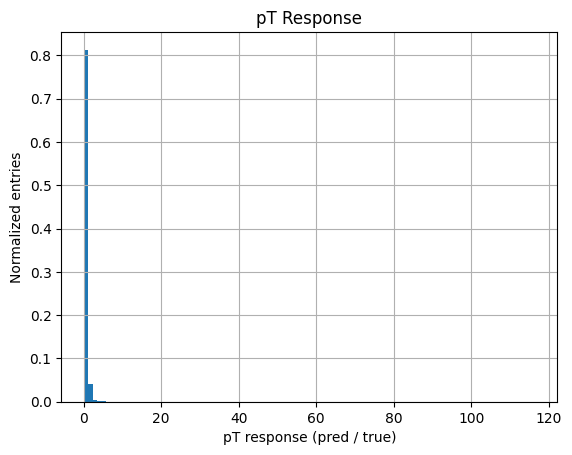

Mean response: 1.04539538082606
Std response: 0.9579361155388286


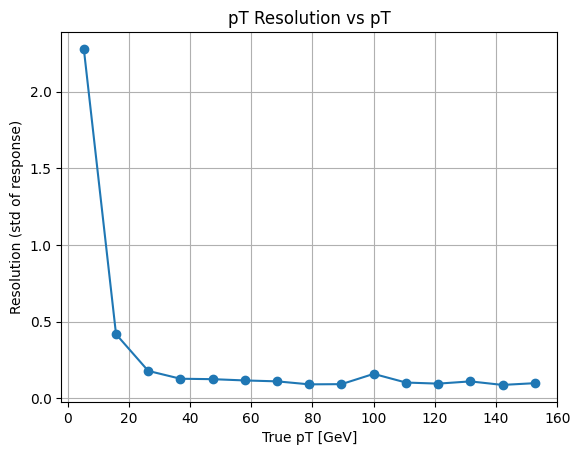

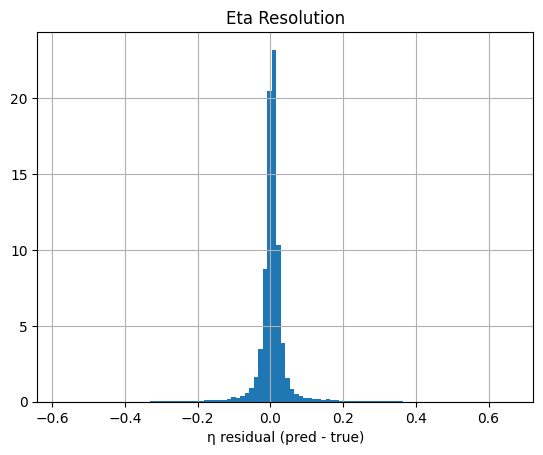

Eta resolution std: 0.04604920327574391


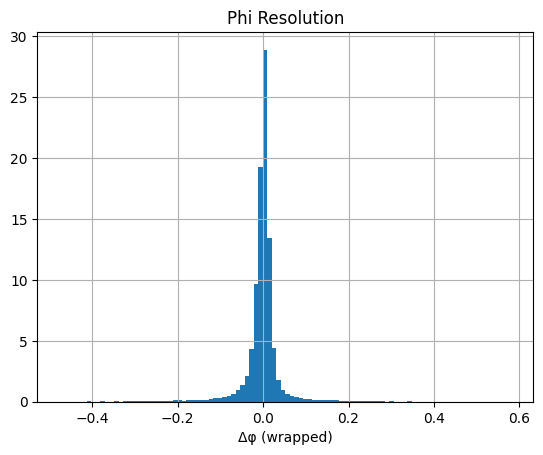

Phi resolution std: 0.04652925124106407


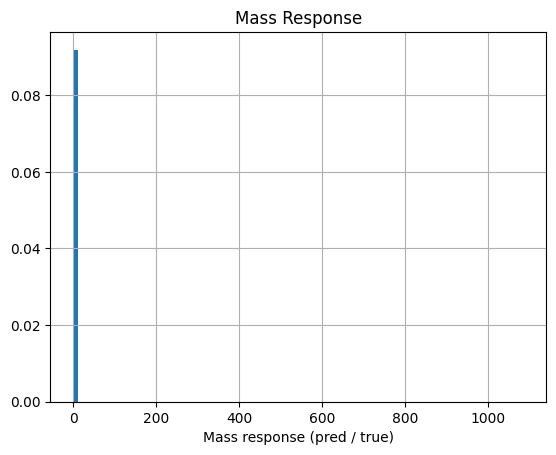

Mean response: 1.282294187646759
Std response: 6.643853872259292


In [21]:
#pt
pred_pt = preds[:,0]
true_pt = targets[:,0]

response = pred_pt / true_pt
response = response[np.isfinite(response)]

plt.figure()
plt.hist(response, bins=100, density=True)
plt.xlabel("pT response (pred / true)")
plt.ylabel("Normalized entries")
plt.title("pT Response")
plt.grid()
plt.show()

print("Mean response:", np.mean(response))
print("Std response:", np.std(response))


bins = np.linspace(0, 200, 20)
bin_centers = 0.5*(bins[1:] + bins[:-1])
resolutions = []

for i in range(len(bins)-1):
    mask = (true_pt >= bins[i]) & (true_pt < bins[i+1])
    if np.sum(mask) > 20:
        r = response[mask]
        resolutions.append(np.std(r))
    else:
        resolutions.append(np.nan)

plt.figure()
plt.plot(bin_centers, resolutions, marker='o')
plt.xlabel("True pT [GeV]")
plt.ylabel("Resolution (std of response)")
plt.title("pT Resolution vs pT")
plt.grid()
plt.show()


# eta
pred_eta = preds[:,1]
true_eta = targets[:,1]

eta_res = pred_eta - true_eta

plt.figure()
plt.hist(eta_res, bins=100, density=True)
plt.xlabel("η residual (pred - true)")
plt.title("Eta Resolution")
plt.grid()
plt.show()

print("Eta resolution std:", np.std(eta_res))


# phi
pred_phi = preds[:,2]
true_phi = targets[:,2]

phi_res = np.arctan2(
    np.sin(pred_phi - true_phi),
    np.cos(pred_phi - true_phi)
)

plt.figure()
plt.hist(phi_res, bins=100, density=True)
plt.xlabel("Δφ (wrapped)")
plt.title("Phi Resolution")
plt.grid()
plt.show()

print("Phi resolution std:", np.std(phi_res))


# mass
pred_mass = preds[:,3]
true_mass = targets[:,3]

mass_response = pred_mass / true_mass
mass_response = mass_response[np.isfinite(mass_response)]

plt.figure()
plt.hist(mass_response, bins=100, density=True)
plt.xlabel("Mass response (pred / true)")
plt.title("Mass Response")
plt.grid()
plt.show()
print("Mean response:", np.mean(mass_response))
print("Std response:", np.std(mass_response))

In [22]:
print("========== PERFORMANCE ==========")
print("pT mean response:", np.mean(response))
print("pT resolution:", np.std(response))
print("pT IQR:", (np.quantile(response, 0.75) - np.quantile(response, 0.25)))
print("Eta resolution:", np.std(eta_res))
print("Phi resolution:", np.std(phi_res))
print("Mass mean response:", np.mean(mass_response))
print("Mass resolution:", np.std(mass_response))
print("mass IQR:", (np.quantile(mass_response, 0.75) - np.quantile(mass_response, 0.25)))

========== PERFORMANCE ==========
pT mean response: 1.04539538082606
pT resolution: 0.9579361155388286
pT IQR: 0.07105446
Eta resolution: 0.04604920327574391
Phi resolution: 0.04652925124106407
Mass mean response: 1.282294187646759
Mass resolution: 6.643853872259292
mass IQR: 0.29616553
